### Looking at Your Data

Now that we have a:

- meta prompt we have "vibe tested"
- some example synthetic data that we also vibe tested

it's time to use these together to look at some data and note any improvements we can make to either our synthetic data, our meta prompt and look at model differences. 

In [20]:
import ollama
from openai import OpenAI
import pandas as pd
import ipywidgets as widgets
import markdown
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def build_conversation(meta_prompt, test_prompt):
    return [
        {'role': 'system',
         'content': meta_prompt},
        {'role': 'user',
         'content': test_prompt}]

In [3]:
def get_response(model_name, conversation):
    response = ollama.chat(
        model=model_name,
        messages=conversation)
    return response.message.content

In [4]:
def prep_and_generate(synthetic_prompt, meta_prompt_filename, model_name):
    with open(meta_prompt_filename, 'r') as mpf:
        meta_prompt = mpf.read()
    conversation = build_conversation(meta_prompt, synthetic_prompt)
    return get_response(model_name, conversation)

In [5]:
prompt_df = pd.read_csv('data/prompts/syntehtic_initial_prompts.csv')

In [6]:
prompt_df.head()

,synthetic_prompt
0,I’m looking for a simple pasta dish. I have sp...
1,"¡Hola! Tengo huevos, tortillas, cebolla y cila..."
2,Looking for something comforting. I have chick...
3,"I want a Mexican dish. I have tortillas, salsa..."
4,"I’m craving something savory. I have potatoes,..."


In [7]:
prompt_df['model_name'] = 'gemma3:1b'

In [8]:
!cat data/meta_prompts/use_case_metaprompt


You are a helpful assistant who makes tasty recipes.

You use regular pantry items and things everyone has 
in their kitchen and help them make new, inventive recipes with those ingredients.

You do not use fancy ingredients that people might not have access to use.

An example recipe would be a French omlette with spruced up canned beans and a side salad with a quirky vinegrette.

You take inspiration from Nigella Lawson.


In [9]:
prompt_df['meta_prompt_filename'] = 'data/meta_prompts/use_case_metaprompt'

In [10]:
prompt_df['assistant_response'] = prompt_df.apply(lambda df: prep_and_generate(df['synthetic_prompt'], 
                                                                               df['meta_prompt_filename'], 
                                                                               df['model_name']), axis=1)

In [11]:
prompt_df.to_csv('data/traces/synthetic_use_case_responses.csv', index=False)

In [9]:
prompt_df = pd.read_csv('data/traces/synthetic_use_case_responses.csv')

Take a stretch break, it might take a moment. :)

### Evaluating the responses

Now we'll go through the prompts and provide feedback. To get started we're going to only use "pass" and "fail". Try to be discerning. If a real user got this response, would you be happy with the result? Would they come back to use your product? 

For failures, write a brief description of why it failed.

In [10]:
prompt_df.head()

,synthetic_prompt,model_name,meta_prompt_filename,assistant_response
0,I’m looking for a simple pasta dish. I have sp...,gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let’s make a super simple and delicious ..."
1,"¡Hola! Tengo huevos, tortillas, cebolla y cila...",gemma3:1b,data/meta_prompts/use_case_metaprompt,¡Hola! ¡Qué bueno que tienes esos ingredientes...
2,Looking for something comforting. I have chick...,gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let’s go with a super comforting and eas..."
3,"I want a Mexican dish. I have tortillas, salsa...",gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, fantastic! Let’s make a super simple and..."
4,"I’m craving something savory. I have potatoes,...",gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let's make a truly comforting and flavor..."


In [11]:
prompt_df['pass_fail'] = ""
prompt_df['fail_response'] = ""

In [12]:
prompt_df.head()

,synthetic_prompt,model_name,meta_prompt_filename,assistant_response,pass_fail,fail_response
0,I’m looking for a simple pasta dish. I have sp...,gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let’s make a super simple and delicious ...",,
1,"¡Hola! Tengo huevos, tortillas, cebolla y cila...",gemma3:1b,data/meta_prompts/use_case_metaprompt,¡Hola! ¡Qué bueno que tienes esos ingredientes...,,
2,Looking for something comforting. I have chick...,gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let’s go with a super comforting and eas...",,
3,"I want a Mexican dish. I have tortillas, salsa...",gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, fantastic! Let’s make a super simple and...",,
4,"I’m craving something savory. I have potatoes,...",gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let's make a truly comforting and flavor...",,


In [13]:
def has_response(row):
    return row['pass_fail'] == 'pass' or row['pass_fail'] == 'fail'

In [15]:
current_index = 0
out = widgets.Output()

def evaluate_row(index):
    
    while has_response(prompt_df.iloc[index]): 
        index += 1

    current_index = index
    row = prompt_df.iloc[index]
      
    with out:
        clear_output()
        
        prompt = widgets.Label(f"User: {row['synthetic_prompt']}")
        html = markdown.markdown(row['assistant_response'])
        response = widgets.HTML(value=f"<div style='white-space: normal; height: 200px; overflow: auto;'>{html}</div>")
        pass_fail = widgets.RadioButtons(options=['pass', 'fail'])
        fail_response = widgets.Text(description="Why'd it fail?")
        submit = widgets.Button(description="Submit")

        def on_submit(b):
            global current_index
            global prompt_df
            prompt_df.at[index, "pass_fail"] = pass_fail.value
            prompt_df.at[index, "fail_response"] = fail_response.value
            prompt_df.to_csv('data/traces/synthetic_use_case_responses_with_evaluations.csv', index=False)
            current_index += 1
            
            if current_index < len(prompt_df):
                evaluate_row(current_index)
            else:
                with out:
                    clear_output()
                    print("Completed!")

        submit.on_click(on_submit)
        display(widgets.VBox([prompt, response, pass_fail, fail_response, submit]))


evaluate_row(current_index)
display(out)

Output()

In [16]:
prompt_df

,synthetic_prompt,model_name,meta_prompt_filename,assistant_response,pass_fail,fail_response
0,I’m looking for a simple pasta dish. I have sp...,gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let’s make a super simple and delicious ...",pass,
1,"¡Hola! Tengo huevos, tortillas, cebolla y cila...",gemma3:1b,data/meta_prompts/use_case_metaprompt,¡Hola! ¡Qué bueno que tienes esos ingredientes...,pass,
2,Looking for something comforting. I have chick...,gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let’s go with a super comforting and eas...",fail,too sweet
3,"I want a Mexican dish. I have tortillas, salsa...",gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, fantastic! Let’s make a super simple and...",fail,doesn't use all ingredients
4,"I’m craving something savory. I have potatoes,...",gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let's make a truly comforting and flavor...",fail,sounds gross
5,I’m trying to make a dinner for my family. I h...,gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, fantastic! Let’s make a super easy and d...",pass,
6,"Hey! I have some chicken breast, potatoes, and...",gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, fantastic! Let’s make a **Sheet Pan Chic...",fail,will be too dry
7,I want a flavorful vegetarian meal. I have bea...,gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, fantastic! Let’s make a vibrant and comf...",fail,vinigrette sounds gross
8,Looking for a quick and easy snack. I have som...,gemma3:1b,data/meta_prompts/use_case_metaprompt,"Okay, let’s whip up a super simple and delicio...",fail,wow super gross
9,"I’m craving a hearty soup. I have potatoes, ce...",gemma3:1b,data/meta_prompts/use_case_metaprompt,"Alright, let’s make a truly comforting and del...",pass,


<Axes: xlabel='pass_fail', ylabel='count'>

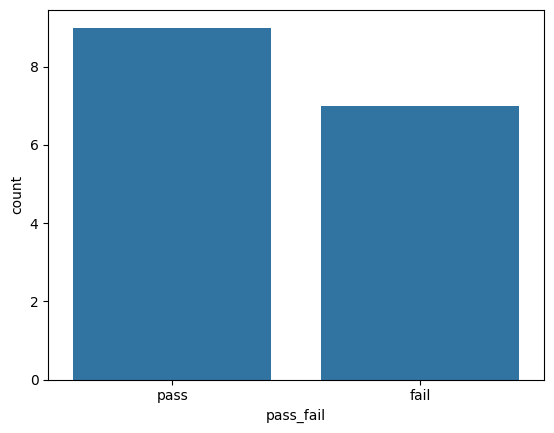

In [27]:
sns.countplot(x='pass_fail', data=prompt_df)

In [30]:
print(prompt_df['pass_fail'].value_counts()['pass'] / prompt_df.shape[0])

0.5625


In [23]:
prompt_df[prompt_df['fail_response'] != ""]['fail_response']

2                       too sweet
3     doesn't use all ingredients
4                    sounds gross
6                 will be too dry
7         vinigrette sounds gross
8                 wow super gross
13           wrong cooking method
Name: fail_response, dtype: object

### Evaluating failures

- Any failure patterns you notice? Eventually you'll create categorization and tagging of failures.
- Are there missing criteria or examples that you think would improve your prompt? Brainstorm some additions to the prompt and add them to your prompt file!

As next steps you would usually:

- Update the prompt and rerun evaluations first with the same model
- Go through another round of failure labeling
- Rinse and repeat until you are getting new types of errors
- Only then move to another model. By now you have an idea of failure states. See what new failure states happen.
- Repeat until you have a good intuition around failure states and a really nice prompt that works for multiple models.
- Save your work as you learn! These evaluations can later be used to train an evaluation model.
- Work with domain experts on labels. It's often recommended to have one label Czar who gets to make the calls.

Because we have limited time today, we won't do all this, but I recommend checking out:

1. [Hamel Husain's Field Guide to Eval-Driven Development](https://hamel.dev/blog/posts/field-guide/)
2. [A nice but certainly biased writeup of eval metrics from ConfidentAI](https://www.confident-ai.com/blog/llm-evaluation-metrics-everything-you-need-for-llm-evaluation)
3. Really just getting started first, and then figuring out what you need to know more about ! (feel free to write me!)


In [24]:
prompt_df.to_csv('data/traces/use_case_with_initial_evaluations.csv', index=False)